In [ ]:
import pandas as pd
from psycopg.rows import dict_row

from careerpulse.database import get_connection

with get_connection() as connection, connection.cursor(row_factory=dict_row) as cursor:
    cursor.execute(
        """
        SELECT job_id, title, company, location, technology,
               salary_min, salary_max, remote, source
        FROM jobs
        WHERE LOWER(location) LIKE '%madrid%'
        ORDER BY job_id
        """
    )
    jobs = pd.DataFrame(cursor.fetchall())

print(f"Ofertas de Madrid: {len(jobs)}")
display(jobs.head())

Ofertas de Madrid: 9


,job_id,title,company,location,technology,salary_min,salary_max,remote,source
0,1,Data Engineer,DataWorks,Madrid,PostgreSQL,32000.0,42000.0,False,csv
1,2,Cloud Engineer,CloudTech,Madrid,AWS,45000.0,60000.0,True,csv
2,3,Frontend Developer,WebLabs,Madrid,JavaScript,30000.0,40000.0,True,csv
3,4,DevOps Engineer,InfraWorks,Madrid,Kubernetes,50000.0,65000.0,False,csv
4,5,Data Engineer,Nexthink,Madrid,Unknown,NaN,NaN,False,adzuna


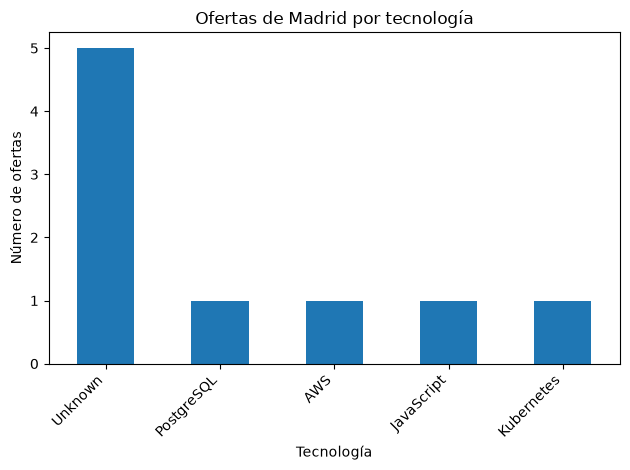

In [6]:
import matplotlib.pyplot as plt

jobs["technology"].value_counts().plot(
    kind="bar",
    title="Ofertas de Madrid por tecnología",
    xlabel="Tecnología",
    ylabel="Número de ofertas",
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

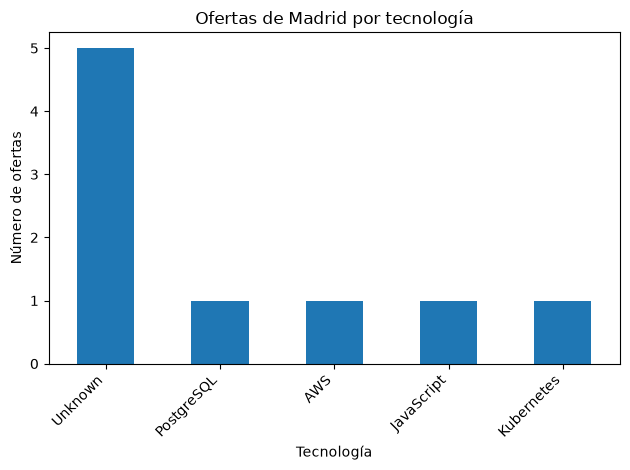

In [8]:
import matplotlib.pyplot as plt

jobs["technology"].value_counts().plot(
    kind="bar",
    title="Ofertas de Madrid por tecnología",
    xlabel="Tecnología",
    ylabel="Número de ofertas",
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
display(
    jobs.groupby("source").agg(
        ofertas=("job_id", "count"),
        tecnologia_desconocida=("technology", lambda values: (values == "Unknown").sum()),
        salarios_disponibles=("salary_min", "count"),
    )
)

,ofertas,tecnologia_desconocida,salarios_disponibles
source,,,
adzuna,5,5,2
csv,4,0,4


## Primeras observaciones

La base de datos contiene 9 ofertas de Madrid: 5 de Adzuna y 4 del CSV.
Las 5 ofertas de Adzuna tienen la tecnología sin identificar (`Unknown`) y
solo 2 incluyen salario mínimo. Por ahora, el gráfico describe estos datos
disponibles, pero no representa el mercado laboral de Madrid.

In [10]:
print("Ofertas por origen:")
display(jobs["source"].value_counts())

print("Ofertas por tecnología:")
display(jobs["technology"].value_counts())


Ofertas por origen:


source
adzuna    5
csv       4
Name: count, dtype: int64

Ofertas por tecnología:


technology
Unknown       5
PostgreSQL    1
AWS           1
JavaScript    1
Kubernetes    1
Name: count, dtype: int64

In [11]:
display(
    jobs.loc[
        jobs["technology"] == "Unknown",
        ["job_id", "title", "company", "source"],
    ]
)

,job_id,title,company,source
4,5,Data Engineer,Nexthink,adzuna
5,6,Data Analyst,RemoteJobsOne,adzuna
6,7,Data Engineer,TAPTAP Digital,adzuna
7,8,Data Analyst,RemoteJobsOne,adzuna
8,9,Data Analyst,MSX International,adzuna
